In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import string
from collections import Counter
from sklearn.preprocessing import LabelEncoder 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\Aditya P J\Documents\Competition\Satria Data 2025\data\video_transcripts.csv")
df.head()

,id,text,durasi,emotion
0,100,we can do you have to make time to reflect wha...,0.51,Proud
1,101,we can do you have to make time to reflect wha...,0.51,Trust
2,102,we can do you have to make time to reflect wha...,0.51,Surprise
3,103,kekuatan otot kaki kalian dengan cara duduk be...,0.57,Surprise
4,104,orang wajib yang perlu aku bawa pas lagi raket...,0.54,Sadness


In [3]:
df_sorted = df.sort_values('id')
print("Ascending")
print(df_sorted)

Ascending
      id                                               text  durasi   emotion
110    1  tradisional Laos kayak gimana Kayak gini jadi ...    1.58  Surprise
221    2  episode berikutnya akan dimulai sekarang kita ...    2.07  Surprise
331    3  itu agak aneh ya biasanya pohon pepaya itu kan...    0.45  Surprise
442    4  bulan ini sampah organik di rumah kita olah Pa...    2.06  Surprise
553    5  mobil yang akan kita pakai buat root party nan...    1.04     Proud
..   ...                                                ...     ...       ...
747  799  bikin website judi slot online nggak Kalau bis...    0.24  Surprise
750  800  bikin Ai buat anak gue yang namanya Zain anak ...    1.20  Surprise
751  801  ada di dalam MacBook gimana ceritanya tuh Bang...    1.35     Proud
752  802  yang katanya teks editor pengganti vscode yang...    2.16     Anger
753  803  ini bisa gantiin kita sebagai seorang programm...    0.57  Surprise

[776 rows x 4 columns]


In [4]:
df_sorted.head()

,id,text,durasi,emotion
110,1,tradisional Laos kayak gimana Kayak gini jadi ...,1.58,Surprise
221,2,episode berikutnya akan dimulai sekarang kita ...,2.07,Surprise
331,3,itu agak aneh ya biasanya pohon pepaya itu kan...,0.45,Surprise
442,4,bulan ini sampah organik di rumah kita olah Pa...,2.06,Surprise
553,5,mobil yang akan kita pakai buat root party nan...,1.04,Proud


In [5]:
df.isnull().sum()

id         0
text       0
durasi     0
emotion    0
dtype: int64

In [31]:
# 2. INFORMASI DASAR DATASET
print("\n1. INFORMASI DASAR DATASET")
print("-" * 40)
print(f"Shape dataset: {df_sorted.shape}")
print(f"Jumlah baris: {df_sorted.shape[0]}")
print(f"Jumlah kolom: {df_sorted.shape[1]}")

print("\nTipe data:")
print(df_sorted.dtypes)

print("\nInfo dataset:")
print(df_sorted.info())

print("\n5 data teratas:")
print(df_sorted.head())


1. INFORMASI DASAR DATASET
----------------------------------------
Shape dataset: (776, 4)
Jumlah baris: 776
Jumlah kolom: 4

Tipe data:
id           int64
text        object
durasi     float64
emotion     object
dtype: object

Info dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 776 entries, 110 to 753
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       776 non-null    int64  
 1   text     776 non-null    object 
 2   durasi   776 non-null    float64
 3   emotion  776 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 30.3+ KB
None

5 data teratas:
     id                                               text  durasi   emotion
110   1  tradisional Laos kayak gimana Kayak gini jadi ...    1.58  Surprise
221   2  episode berikutnya akan dimulai sekarang kita ...    2.07  Surprise
331   3  itu agak aneh ya biasanya pohon pepaya itu kan...    0.45  Surprise
442   4  bulan ini sampah organik 

In [33]:
duplikat = df.duplicated()
print('Baris duplikat (seluruh kolom) :')
print(duplikat)
print('\nJumlah Duplikat:', duplikat.sum())

Baris duplikat (seluruh kolom) :
0      False
1      False
2      False
3      False
4      False
       ...  
771    False
772    False
773    False
774    False
775    False
Length: 776, dtype: bool

Jumlah Duplikat: 0


In [35]:
# Cek duplikat berdasarkan kolom 'id'
duplikat_text = df.duplicated(subset=['text'])
print("Duplikat berdasarkan text:")
print(duplikat_text)
print("Jumlah duplikat text:", duplikat_text.sum())


Duplikat berdasarkan text:
0      False
1       True
2       True
3      False
4      False
       ...  
771     True
772     True
773     True
774     True
775    False
Length: 776, dtype: bool
Jumlah duplikat text: 71


In [37]:
# Tampilkan duplikat berdasarkan ID
duplikat_text_all = df_sorted[df_sorted.duplicated(subset=['text'], keep=False)]
print("\nData dengan ID duplikat:")
print(duplikat_text_all)


Data dengan ID duplikat:
      id                                               text  durasi emotion
375   43                         Could not understand audio    3.54   Anger
705   75  we can do you have to make time to reflect wha...    0.51   Proud
716   76  we can do you have to make time to reflect wha...    0.51   Trust
763   89  we can do you have to make time to reflect wha...    0.51   Trust
765   90  we can do you have to make time to reflect wha...    0.51    Fear
..   ...                                                ...     ...     ...
724  777                         Could not understand audio    0.54   Trust
728  780                         Could not understand audio    0.18   Proud
731  783                         Could not understand audio    0.58   Proud
742  793                         Could not understand audio    4.48   Proud
743  794                         Could not understand audio    3.41     Joy

[93 rows x 4 columns]


In [39]:
index_to_drop = df_sorted[
    df_sorted['text'].str.contains('Could not understand audio', case=False, na=False) |
    df_sorted['text'].str.contains('we can do you have to make time to reflect', case=False, na=False) |
    df_sorted['text'].str.contains('kantong ngasih trend Korean flash look Aku', case=False, na=False)
].index

df_clean = df.drop(index_to_drop)
print("Data setelah drop :")
print(df_clean)

Data setelah drop :
      id                                               text  durasi   emotion
3    103  kekuatan otot kaki kalian dengan cara duduk be...    0.57  Surprise
4    104  orang wajib yang perlu aku bawa pas lagi raket...    0.54   Sadness
6    106  nah Kemarin kan sudah ngasih tahu spill trick ...    1.05     Proud
7    107  dibuat jadi alat pemersatu bangsa dan itu terb...    0.18  Surprise
9    109  lagi istirahat dulu udah 2 lap tinggal satu la...    0.42     Proud
..   ...                                                ...     ...       ...
760   86  Bismillahirohmanirohim Papa Mama hari ini kan ...    1.35     Trust
761   87  suka kesel kalau bulu matanya jadi bleber air ...    0.50     Proud
762   88  aku ke mana aja penemu hidden Jerry swace loka...    0.43  Surprise
764    8  sebelumnya Peserta top 10 Firaun business on t...    1.19     Proud
775    9  destinator akhirnya diumumkan di giias 2025 da...    1.27     Trust

[722 rows x 4 columns]


In [41]:
# Tampilkan duplikat berdasarkan ID
duplikat_text_all = df_clean[df_clean.duplicated(subset=['text'], keep=False)]
print("\nData dengan ID duplikat:")
print(duplikat_text_all)


Data dengan ID duplikat:
      id                                               text  durasi   emotion
157  242  3 penempatan belas kalian Aku mau nyobain prod...    1.28     Trust
158  243  3 penempatan belas kalian Aku mau nyobain prod...    1.28     Trust
159  244  birthday party invitation ever karena Maybelli...    1.08  Surprise
160  245  birthday party invitation ever karena Maybelli...    1.08   Sadness
161  246  birthday party invitation ever karena Maybelli...    1.08     Trust
360  426  Walking protokol jadi caranya itu kalian jalan...    0.39     Anger
362  428  gerakan unik ini nih dan gila nyeri bahu berta...    1.09     Proud
366  431  pas lagi workout ya Atau kau bolak-balik nafas...    0.48     Trust
367  432  berat kayak galon atau tas belajar atau apapun...    0.56     Proud
368  433  berat kayak galon atau tas belajar atau apapun...    0.56     Trust
369  434  aku dapetin dengan dua hal yaitu lari pagi dul...    1.53  Surprise
370  435  menarik nih Yuk kita coba ya

In [43]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 722 entries, 3 to 775
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       722 non-null    int64  
 1   text     722 non-null    object 
 2   durasi   722 non-null    float64
 3   emotion  722 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 28.2+ KB


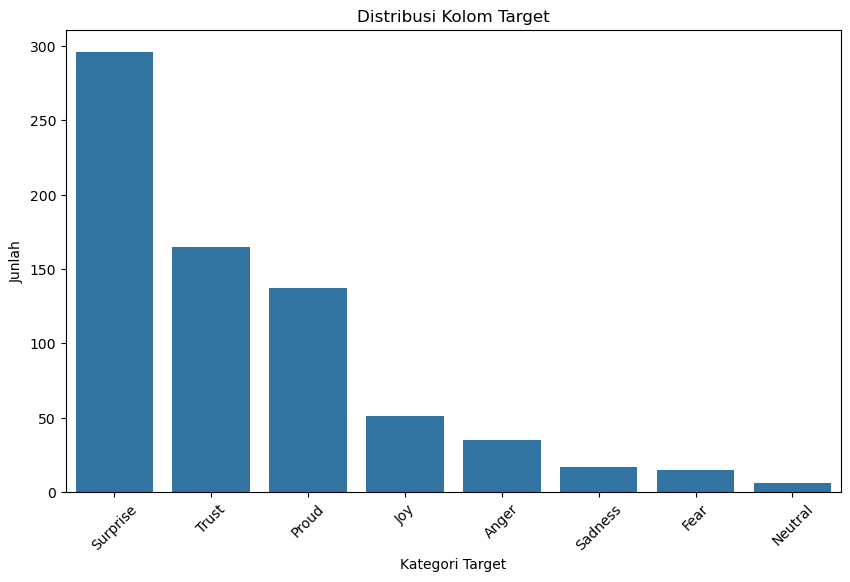

In [45]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='emotion', order=df_clean['emotion'].value_counts().index)
plt.title('Distribusi Kolom Target')
plt.xlabel('Kategori Target')
plt.ylabel('Junlah')
plt.xticks(rotation=45)
plt.show()

In [46]:
def clean_text(text):
    """
    Fungsi untuk membersihkan teks
    """
    if pd.isna(text):
        return ""
    
    # Konversi ke lowercase
    text = text.lower()
    
    # Hapus angka
    text = re.sub(r'\d+', '', text)
    
    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Hapus whitespace berlebih
    text = ' '.join(text.split())
    
    return text

In [49]:
df_clean['text_cleaned'] = df_clean['text'].apply(clean_text)

print("Contoh text sebelum dan sesudah preprocessing:")
for i in range(min(3, len(df_clean))):
    print(f"\nOriginal: {df_clean.iloc[i]['text']}")
    print(f"Cleaned:  {df_clean.iloc[i]['text_cleaned']}")

Contoh text sebelum dan sesudah preprocessing:

Original: kekuatan otot kaki kalian dengan cara duduk berdiri di kursi ya tangan di bahu kemudian lakukan 1 menit sebanyak-banyaknya Jadi harus cepat seperti ini 1 menit lagi hasilnya 71 Dari jurnal systematic review ini memperlihatkan bahwa jumlah 20 sampai 50 itu sudah rata-rata dan bagus banget Jadi kalau teman-teman berada di angkasa begitu udah oke namun kalau bisa lebih di atas 50 yaitu bagus banget berapa nilaimu
Cleaned:  kekuatan otot kaki kalian dengan cara duduk berdiri di kursi ya tangan di bahu kemudian lakukan menit sebanyakbanyaknya jadi harus cepat seperti ini menit lagi hasilnya dari jurnal systematic review ini memperlihatkan bahwa jumlah sampai itu sudah ratarata dan bagus banget jadi kalau temanteman berada di angkasa begitu udah oke namun kalau bisa lebih di atas yaitu bagus banget berapa nilaimu

Original: orang wajib yang perlu aku bawa pas lagi raket selain rakyat banyak banget yang harus dibawa pas fedel Tumblr ik

In [51]:
# 5. ENCODE EMOTION LABELS
print("\n4. ENCODING EMOTION LABELS")
print("-" * 40)

# Buat label encoder untuk emotion
label_encoder = LabelEncoder()
df_clean['emotion_encoded'] = label_encoder.fit_transform(df_clean['emotion'])

# Tampilkan mapping emotion ke angka
emotion_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapping Emotion ke Angka:")
for emotion, code in emotion_mapping.items():
    print(f"{emotion}: {code}")

print("\nDataset setelah encoding:")
print(df_clean[['emotion', 'emotion_encoded']].head())


4. ENCODING EMOTION LABELS
----------------------------------------
Mapping Emotion ke Angka:
Anger: 0
Fear: 1
Joy: 2
Neutral: 3
Proud: 4
Sadness: 5
Surprise: 6
Trust: 7

Dataset setelah encoding:
    emotion  emotion_encoded
3  Surprise                6
4   Sadness                5
6     Proud                4
7  Surprise                6
9     Proud                4


In [53]:
# 7. ANALISIS DISTRIBUSI EMOTION
print("\n6. ANALISIS DISTRIBUSI EMOTION")
print("-" * 40)

emotion_counts = df_clean['emotion'].value_counts()
print("Distribusi Emotion:")
print(emotion_counts)

emotion_percentage = df_clean['emotion'].value_counts(normalize=True) * 100
print("\nPersentase Emotion:")
for emotion, pct in emotion_percentage.items():
    print(f"{emotion}: {pct:.2f}%")

# 8. VISUALISASI
print("\n7. MEMBUAT VISUALISASI")
print("-" * 40)


6. ANALISIS DISTRIBUSI EMOTION
----------------------------------------
Distribusi Emotion:
emotion
Surprise    296
Trust       165
Proud       137
Joy          51
Anger        35
Sadness      17
Fear         15
Neutral       6
Name: count, dtype: int64

Persentase Emotion:
Surprise: 41.00%
Trust: 22.85%
Proud: 18.98%
Joy: 7.06%
Anger: 4.85%
Sadness: 2.35%
Fear: 2.08%
Neutral: 0.83%

7. MEMBUAT VISUALISASI
----------------------------------------


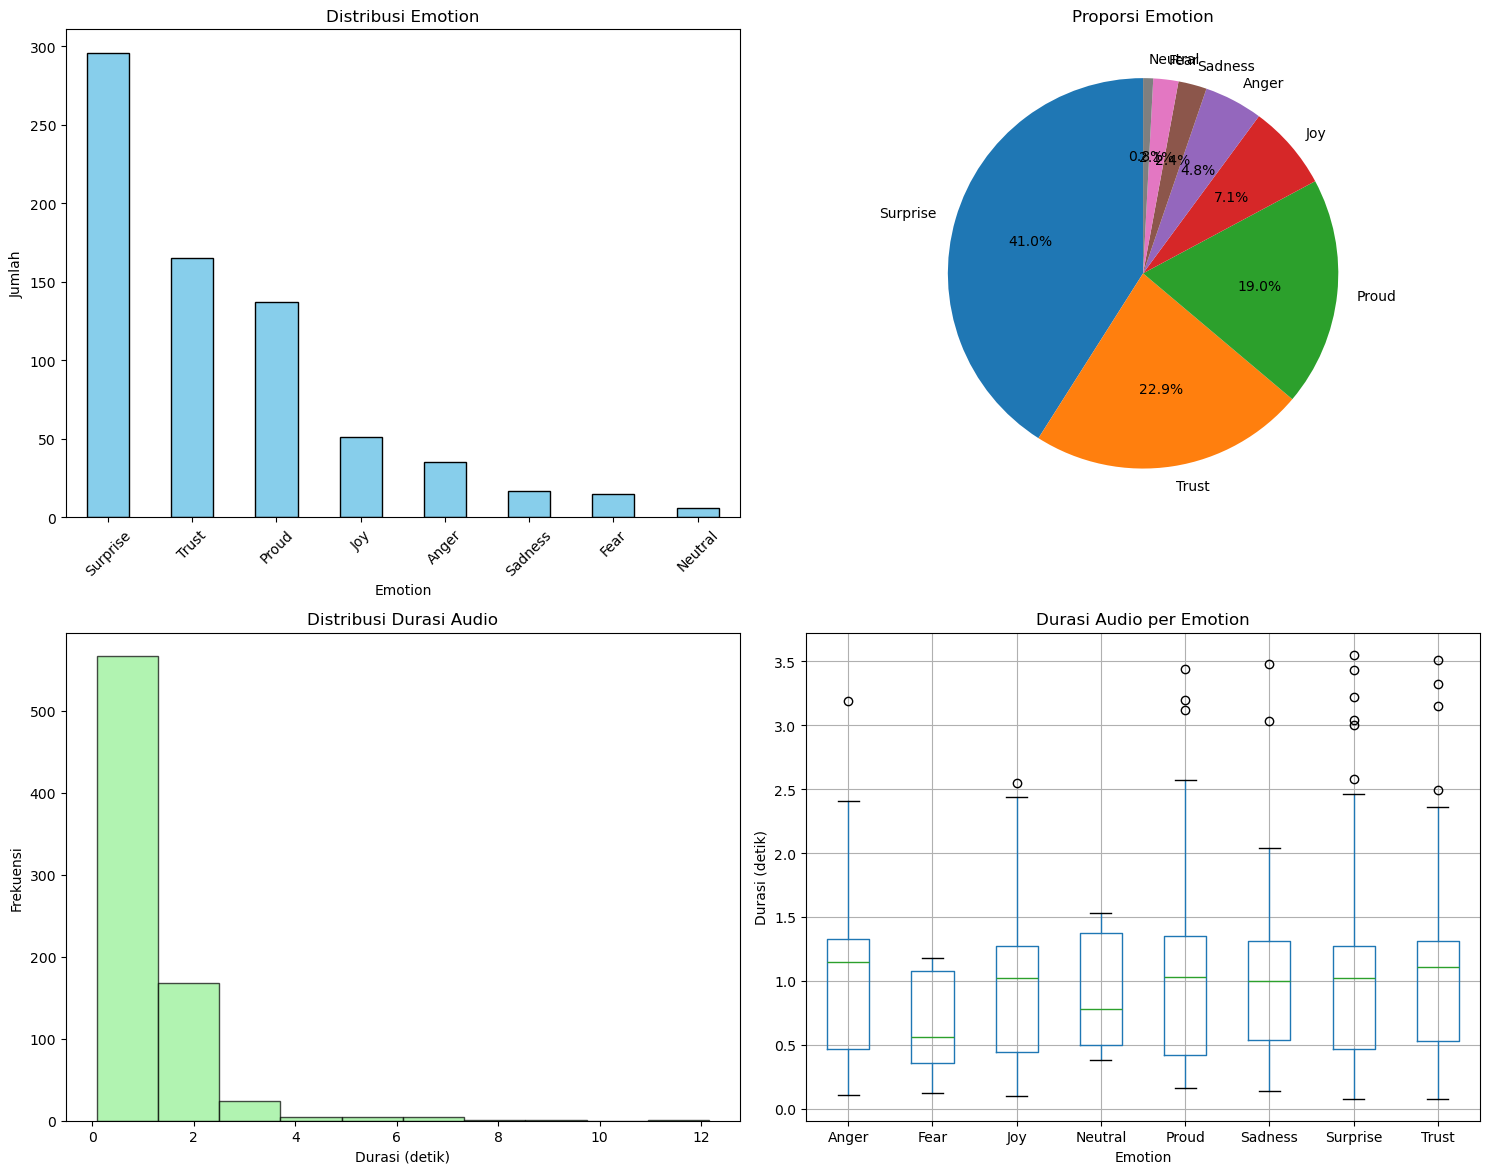

In [55]:
# Setup untuk subplot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Exploratory Data Analysis - Dataset Emosi', fontsize=16, fontweight='bold')

# 1. Distribusi Emotion (Bar Plot)
emotion_counts.plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribusi Emotion')
axes[0,0].set_xlabel('Emotion')
axes[0,0].set_ylabel('Jumlah')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Distribusi Emotion (Pie Chart)
axes[0,1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Proporsi Emotion')

# 3. Distribusi Durasi
axes[1,0].hist(df['durasi'], bins=10, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1,0].set_title('Distribusi Durasi Audio')
axes[1,0].set_xlabel('Durasi (detik)')
axes[1,0].set_ylabel('Frekuensi')

# 4. Durasi vs Emotion (Box Plot)
df_clean.boxplot(column='durasi', by='emotion', ax=axes[1,1])
axes[1,1].set_title('Durasi Audio per Emotion')
axes[1,1].set_xlabel('Emotion')
axes[1,1].set_ylabel('Durasi (detik)')
plt.suptitle('') # Remove automatic title

plt.tight_layout()
plt.show()

In [56]:
# Save ke CSV
df_clean.to_csv('data_baru.csv', index=False)
print("File disimpan sebagai 'new_clean_data.csv'")

File disimpan sebagai 'new_clean_data.csv'


In [59]:
df_new = pd.read_csv(r"C:\Users\Aditya P J\Documents\Competition\Satria Data 2025\data\data_baru.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Aditya P J\\Documents\\Competition\\Satria Data 2025\\data\\data_baru.csv'

In [ ]:
df_neww = df_new.drop(['text'], axis=1)
df_neww.head()

In [74]:
df_newww = df_neww.rename(columns={
    'text_cleaned' : 'text'})
df_newww.head()

,id,durasi,text,emotion
0,103,0.57,kekuatan otot kaki kalian dengan cara duduk be...,6
1,104,0.54,orang wajib yang perlu aku bawa pas lagi raket...,5
2,106,1.05,nah kemarin kan sudah ngasih tahu spill trick ...,4
3,107,0.18,dibuat jadi alat pemersatu bangsa dan itu terb...,6
4,109,0.42,lagi istirahat dulu udah lap tinggal satu lap ...,4


In [78]:
df_reordered = df_newww[['id', 'text', 'durasi', 'emotion']]
df_reordered.head()

,id,text,durasi,emotion
0,103,kekuatan otot kaki kalian dengan cara duduk be...,0.57,6
1,104,orang wajib yang perlu aku bawa pas lagi raket...,0.54,5
2,106,nah kemarin kan sudah ngasih tahu spill trick ...,1.05,4
3,107,dibuat jadi alat pemersatu bangsa dan itu terb...,0.18,6
4,109,lagi istirahat dulu udah lap tinggal satu lap ...,0.42,4


In [80]:
df_sort = df_reordered.sort_values('id')
print("Ascending")
print(df_sort)

Ascending
      id                                               text  durasi  emotion
103    1  tradisional laos kayak gimana kayak gini jadi ...    1.58        6
200    2  episode berikutnya akan dimulai sekarang kita ...    2.07        6
308    3  itu agak aneh ya biasanya pohon pepaya itu kan...    0.45        6
417    4  bulan ini sampah organik di rumah kita olah pa...    2.06        6
521    5  mobil yang akan kita pakai buat root party nan...    1.04        4
..   ...                                                ...     ...      ...
704  799  bikin website judi slot online nggak kalau bis...    0.24        6
707  800  bikin ai buat anak gue yang namanya zain anak ...    1.20        6
708  801  ada di dalam macbook gimana ceritanya tuh bang...    1.35        4
709  802  yang katanya teks editor pengganti vscode yang...    2.16        0
710  803  ini bisa gantiin kita sebagai seorang programm...    0.57        6

[722 rows x 4 columns]


In [82]:
# Save ke CSV
df_sort.to_csv('fix_clean_data.csv', index=False)
print("File disimpan")

File disimpan


## TF-IDF

In [2]:
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import SMOTE
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Download NLTK data (run once)
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except:
    pass

In [6]:
class TextPreprocessor:
    def __init__(self, language='indonesian'):
        self.language = language
        self.stemmer = PorterStemmer()
        try:
            self.stop_words = set(stopwords.words(language))
        except:
            # Jika bahasa tidak tersedia, gunakan english
            self.stop_words = set(stopwords.words('english'))
        
        # Tambahan stopwords bahasa Indonesia
        if language == 'indonesian':
            additional_stopwords = {
                'yang', 'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'dalam', 'oleh',
                'dan', 'atau', 'tapi', 'tetapi', 'karena', 'sebab', 'jika', 'kalau',
                'ini', 'itu', 'tersebut', 'adalah', 'akan', 'telah', 'sudah',
                'ada', 'tidak', 'bukan', 'belum', 'dapat', 'bisa', 'harus'
            }
            self.stop_words.update(additional_stopwords)

    def clean_text(self, text):
        """Basic text cleaning"""
        if pd.isna(text):
            return ""
        
        # Convert to string
        text = str(text)
        
        # Convert to lowercase
        text = text.lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www.\S+', '', text)
        
        # Remove email
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove mentions and hashtags
        text = re.sub(r'@\w+|#\w+', '', text)
        
        # Remove numbers (optional)
        text = re.sub(r'\d+', '', text)
        
        # Remove punctuation and special characters
        text = re.sub(r'[^\w\s]', ' ', text)
        
        # Remove extra whitespaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def tokenize_text(self, text):
        """Tokenize text"""
        try:
            tokens = word_tokenize(text)
        except:
            # Fallback to simple split
            tokens = text.split()
        return tokens
    
    def remove_stopwords(self, tokens):
        """Remove stopwords"""
        return [token for token in tokens if token not in self.stop_words and len(token) > 2]
    
    def stem_tokens(self, tokens):
        """Apply stemming"""
        return [self.stemmer.stem(token) for token in tokens]
    
    def preprocess_text(self, text, remove_stopwords=True, apply_stemming=False):
        """Complete text preprocessing pipeline"""
        # Clean text
        text = self.clean_text(text)
        
        if not text:
            return ""
        
        # Tokenize
        tokens = self.tokenize_text(text)
        
        # Remove stopwords
        if remove_stopwords:
            tokens = self.remove_stopwords(tokens)
        
        # Apply stemming
        if apply_stemming:
            tokens = self.stem_tokens(tokens)
        
        # Join back to text
        return " ".join(tokens)

def load_and_preprocess_data(csv_path, text_column='text', emotion_column='emotion'):
    """Load data dan preprocessing"""
    print("=" * 60)
    print("STEP 1: LOADING AND CLEANING DATA")
    print("=" * 60)
    
    # Load data
    df = pd.read_csv(csv_path)
    print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"Columns: {df.columns.tolist()}")
    
    # Check missing values
    print(f"\nMissing values:")
    print(f"- {text_column}: {df[text_column].isnull().sum()}")
    print(f"- {emotion_column}: {df[emotion_column].isnull().sum()}")
    
    # Remove missing values
    df_clean = df.dropna(subset=[text_column, emotion_column]).copy()
    print(f"\nData after removing missing values: {df_clean.shape[0]} rows")
    
    # Display emotion distribution
    print(f"\nOriginal emotion distribution:")
    emotion_counts = df_clean[emotion_column].value_counts().sort_index()
    for emotion, count in emotion_counts.items():
        print(f"  Emotion {emotion}: {count} samples")
    
    return df_clean

def preprocess_texts(df, text_column='text', 
                    remove_stopwords=True, 
                    apply_stemming=False,
                    language='indonesian'):
    """Preprocessing semua teks dalam dataset"""
    print("\n" + "=" * 60)
    print("STEP 2: TEXT PREPROCESSING")
    print("=" * 60)
    
    # Initialize preprocessor
    preprocessor = TextPreprocessor(language=language)
    
    print(f"Settings:")
    print(f"- Remove stopwords: {remove_stopwords}")
    print(f"- Apply stemming: {apply_stemming}")
    print(f"- Language: {language}")
    
    # Preprocess texts
    print(f"\nProcessing {len(df)} texts...")
    df['text_processed'] = df[text_column].apply(
        lambda x: preprocessor.preprocess_text(x, remove_stopwords, apply_stemming)
    )
    
    # Remove empty processed texts
    df = df[df['text_processed'].str.len() > 0].copy()
    print(f"Data after removing empty processed texts: {len(df)} rows")
    
    # Show examples
    print(f"\nText preprocessing examples:")
    for i in range(min(3, len(df))):
        print(f"\nExample {i+1}:")
        print(f"Original: {df.iloc[i][text_column][:100]}...")
        print(f"Processed: {df.iloc[i]['text_processed'][:100]}...")
    
    return df

def vectorize_texts(df, text_column='text_processed', 
                   method='tfidf',
                   max_features=1000,
                   ngram_range=(1, 2)):
    """Convert text to numerical features"""
    print("\n" + "=" * 60)
    print("STEP 3: TEXT VECTORIZATION")
    print("=" * 60)
    
    print(f"Vectorization settings:")
    print(f"- Method: {method}")
    print(f"- Max features: {max_features}")
    print(f"- N-gram range: {ngram_range}")
    
    if method == 'tfidf':
        vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=2,  # Minimal document frequency
            max_df=0.95,  # Maksimal document frequency
            lowercase=True
        )
    elif method == 'count':
        vectorizer = CountVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=2,
            max_df=0.95,
            lowercase=True
        )
    else:
        raise ValueError("Method harus 'tfidf' atau 'count'")
    
    # Fit and transform
    print(f"\nVectorizing texts...")
    X = vectorizer.fit_transform(df[text_column])
    
    print(f"Vectorization results:")
    print(f"- Shape: {X.shape}")
    print(f"- Sparsity: {(1 - X.nnz / (X.shape[0] * X.shape[1])) * 100:.2f}%")
    print(f"- Feature names sample: {vectorizer.get_feature_names_out()[:10]}")
    
    return X, vectorizer

def apply_resampling(X, y, target_distribution, method_config):
    """Apply oversampling and undersampling"""
    print("\n" + "=" * 60)
    print("STEP 4: RESAMPLING")
    print("=" * 60)
    
    print("Current distribution:")
    current_dist = Counter(y)
    for emotion, count in sorted(current_dist.items()):
        print(f"  Emotion {emotion}: {count}")
    
    print(f"\nTarget distribution:")
    for emotion, count in sorted(target_distribution.items()):
        current_count = current_dist.get(emotion, 0)
        action = "undersample" if current_count > count else "oversample" if current_count < count else "no change"
        print(f"  Emotion {emotion}: {current_count} -> {count} ({action})")
    
    # Konversi sparse matrix ke dense untuk resampling
    X_dense = X.toarray() if hasattr(X, 'toarray') else X
    
    # Pisahkan berdasarkan action yang diperlukan
    X_final = []
    y_final = []
    
    for emotion, target_count in target_distribution.items():
        if emotion not in current_dist:
            print(f"Warning: Emotion {emotion} not found in data, skipping...")
            continue
            
        current_count = current_dist[emotion]
        mask = y == emotion
        X_emotion = X_dense[mask]
        y_emotion = y[mask]
        
        print(f"\nProcessing emotion {emotion}...")
        
        if current_count > target_count:
            # Undersampling
            print(f"  Undersampling: {current_count} -> {target_count}")
            
            if len(set(y)) > 1:  # Perlu minimal 2 classes untuk NearMiss
                try:
                    # Buat dataset sementara dengan class lain
                    other_emotions = [e for e in current_dist.keys() if e != emotion]
                    other_emotion = other_emotions[0]
                    other_mask = y == other_emotion
                    X_other = X_dense[other_mask][:min(50, sum(other_mask))]
                    y_other = y[other_mask][:len(X_other)]
                    
                    # Gabungkan untuk NearMiss
                    X_temp = np.vstack([X_emotion, X_other])
                    y_temp = np.hstack([y_emotion, y_other])
                    
                    # Apply NearMiss
                    nm = NearMiss(version=1, n_neighbors=min(3, current_count-1))
                    X_resampled, y_resampled = nm.fit_resample(X_temp, y_temp)
                    
                    # Ambil hanya emotion yang diproses
                    emotion_mask = y_resampled == emotion
                    X_result = X_resampled[emotion_mask]
                    y_result = y_resampled[emotion_mask]
                    
                    # Jika masih terlalu banyak, random sample
                    if len(y_result) > target_count:
                        indices = np.random.choice(len(y_result), target_count, replace=False)
                        X_result = X_result[indices]
                        y_result = y_result[indices]
                        
                except Exception as e:
                    print(f"  NearMiss failed: {e}, using random undersampling")
                    # Random undersampling sebagai fallback
                    indices = np.random.choice(current_count, target_count, replace=False)
                    X_result = X_emotion[indices]
                    y_result = y_emotion[indices]
            else:
                # Random undersampling
                indices = np.random.choice(current_count, target_count, replace=False)
                X_result = X_emotion[indices]
                y_result = y_emotion[indices]
                
        elif current_count < target_count:
            # Oversampling
            print(f"  Oversampling: {current_count} -> {target_count}")
            
            if len(set(y)) > 1 and current_count > 1:  # Perlu minimal 2 classes dan 2 samples
                try:
                    # Buat dataset sementara dengan class lain
                    other_emotions = [e for e in current_dist.keys() if e != emotion]
                    other_emotion = other_emotions[0]
                    other_mask = y == other_emotion
                    X_other = X_dense[other_mask][:min(current_count, sum(other_mask))]
                    y_other = y[other_mask][:len(X_other)]
                    
                    # Gabungkan untuk SMOTE
                    X_temp = np.vstack([X_emotion, X_other])
                    y_temp = np.hstack([y_emotion, y_other])
                    
                    # Apply SMOTE
                    smote = SMOTE(
                        sampling_strategy={emotion: target_count},
                        k_neighbors=min(current_count-1, method_config.get('k_neighbors', 5)),
                        random_state=42
                    )
                    X_resampled, y_resampled = smote.fit_resample(X_temp, y_temp)
                    
                    # Ambil hanya emotion yang diproses
                    emotion_mask = y_resampled == emotion
                    X_result = X_resampled[emotion_mask]
                    y_result = y_resampled[emotion_mask]
                    
                except Exception as e:
                    print(f"  SMOTE failed: {e}, using random oversampling")
                    # Random oversampling sebagai fallback
                    indices = np.random.choice(current_count, target_count, replace=True)
                    X_result = X_emotion[indices]
                    y_result = np.array([emotion] * target_count)
            else:
                # Random oversampling
                indices = np.random.choice(current_count, target_count, replace=True)
                X_result = X_emotion[indices]
                y_result = np.array([emotion] * target_count)
        else:
            # Tidak perlu resampling
            print(f"  No resampling needed: {current_count}")
            X_result = X_emotion
            y_result = y_emotion
        
        X_final.append(X_result)
        y_final.append(y_result)
        print(f"  Final count: {len(y_result)}")
    
    # Gabungkan semua hasil
    X_resampled = np.vstack(X_final)
    y_resampled = np.hstack(y_final)
    
    print(f"\nResampling results:")
    final_dist = Counter(y_resampled)
    for emotion, count in sorted(final_dist.items()):
        print(f"  Emotion {emotion}: {count}")
    
    print(f"\nTotal samples: {len(y_resampled)}")
    
    return X_resampled, y_resampled

def main_pipeline(csv_path, 
                 target_distribution,
                 text_column='text',
                 emotion_column='emotion',
                 preprocessing_config=None,
                 vectorization_config=None,
                 resampling_config=None):
    """Main pipeline untuk text preprocessing dan resampling"""
    
    # Default configurations
    if preprocessing_config is None:
        preprocessing_config = {
            'remove_stopwords': True,
            'apply_stemming': False,
            'language': 'indonesian'
        }
    
    if vectorization_config is None:
        vectorization_config = {
            'method': 'tfidf',
            'max_features': 1000,
            'ngram_range': (1, 2)
        }
    
    if resampling_config is None:
        resampling_config = {
            'k_neighbors': 5
        }
    
    print("TEXT PREPROCESSING AND RESAMPLING PIPELINE")
    print("=" * 60)
    
    try:
        # Step 1: Load and clean data
        df = load_and_preprocess_data(csv_path, text_column, emotion_column)
        
        # Step 2: Preprocess texts
        df = preprocess_texts(df, text_column, **preprocessing_config)
        
        # Step 3: Vectorize texts
        X, vectorizer = vectorize_texts(df, 'text_processed', **vectorization_config)
        y = df[emotion_column].values
        
        # Step 4: Apply resampling
        X_resampled, y_resampled = apply_resampling(X, y, target_distribution, resampling_config)
        
        # Step 5: Save results
        print("\n" + "=" * 60)
        print("STEP 5: SAVING RESULTS")
        print("=" * 60)
        
        # Create result dataframe
        result_df = pd.DataFrame({
            'emotion': y_resampled,
            'sample_index': range(len(y_resampled))
        })
        
        # Save to CSV
        output_path = 'emotion_data_resampled.csv'
        result_df.to_csv(output_path, index=False)
        print(f"Results saved to: {output_path}")
        
        # Save vectorizer
        import joblib
        joblib.dump(vectorizer, 'text_vectorizer.pkl')
        print("Vectorizer saved to: text_vectorizer.pkl")
        
        print(f"\nFinal summary:")
        print(f"- Total samples: {len(y_resampled)}")
        print(f"- Features: {X_resampled.shape[1]}")
        print(f"- Emotion distribution: {dict(Counter(y_resampled))}")
        
        return X_resampled, y_resampled, vectorizer, result_df
        
    except Exception as e:
        print(f"Error in pipeline: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None, None

# Contoh penggunaan
if __name__ == "__main__":
    # Konfigurasi
    csv_path = "your_data.csv"  # Ganti dengan path file Anda
    
    # Target distribution sesuai requirement
    target_distribution = {
        0: 130,
        1: 130, 
        2: 160,  # Anggap ini adalah "Surprise"
        3: 130,
        4: 130,
        5: 130,
        6: 130,
        7: 130
    }
    
    # Konfigurasi preprocessing
    preprocessing_config = {
        'remove_stopwords': True,
        'apply_stemming': False,  # Set True jika ingin stemming
        'language': 'indonesian'  # Atau 'english'
    }
    
    # Konfigurasi vectorization
    vectorization_config = {
        'method': 'tfidf',  # Atau 'count'
        'max_features': 1000,
        'ngram_range': (1, 2)  # unigram dan bigram
    }
    
    # Jalankan pipeline
    X_resampled, y_resampled, vectorizer, result_df = main_pipeline(
        csv_path=csv_path,
        target_distribution=target_distribution,
        preprocessing_config=preprocessing_config,
        vectorization_config=vectorization_config
    )
    
    if X_resampled is not None:
        print("Pipeline completed successfully!")
    else:
        print("Pipeline failed!")